In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import random
from sklearn.metrics import r2_score


data_dict = pd.read_csv("data_dictionary.csv")
adj_price = pd.read_csv("adjprice.csv")
sectors = pd.read_csv("SP500.csv")
sector_df = sectors.rename(columns={"Symbol": "ticker"})

adj_price["Date"] = pd.to_datetime(adj_price["Date"], format="%Y%m%d")
adj_price = adj_price.set_index("Date")
#adj_price = adj_price[adj_price.index.dayofweek < 5]

Now I am going to rename the columns to their tickers and create a dataframe for matching tickers and names


In [3]:
adj_price=adj_price.rename(columns=lambda x: x.replace(" US Equity", ""))
names = pd.DataFrame(index = adj_price.columns)
names.index.name = "ticker"
names = names.iloc[0:]
names = names.merge(sector_df, on = "ticker",  how = "left")
names.index = names["ticker"]
names = names.drop(columns = ["ticker"])

In [4]:
df = adj_price

## First easy analysis will be only taking into consideration the stocks that were in the S&P 500 throughout at least 90% of the date range



In [6]:
coverage = df.notna().mean()
df = df.loc[:,coverage >= 0.9]

In [7]:
df = df.dropna()
df = df[~df.iloc[:, 1:].duplicated()]
df = df.drop(df.columns[1], axis=1)

In [8]:
df.head()

ticker,1436513D,AAPL,ABC,ABMD,ABT,ABX,ADBE,ADI,ADM,ADP,...,WY,X,XEL,XL,XLNX,XOM,XRAY,XRX,YRCW,ZION
Date,,,,,,,,,,,,,,,,,,,,,
1996-02-28,3.9666,0.8753,2.9793,6.063,5.4616,23.8016,4.1685,7.2854,9.5428,10.3097,...,8.0538,23.0299,8.5667,19.6972,8.2626,10.7800,5.8269,40.5005,72042.1892,13.4914
1996-02-29,4.0085,0.8674,2.9793,6.063,5.5111,23.6065,4.1377,7.0556,9.3605,9.9564,...,7.8455,22.5986,8.4594,19.2825,7.0334,10.9522,5.7542,39.3304,71637.4578,13.4232
1996-03-01,3.9037,0.8477,2.8766,6.438,5.5771,23.5089,4.0296,6.5634,9.4212,10.0848,...,7.7761,22.6849,8.6096,19.3517,5.6905,10.9867,5.6453,39.1417,72042.1892,13.5142
1996-03-04,4.0434,0.8280,2.9279,6.063,5.7916,22.5335,3.9987,6.4321,9.4212,9.9564,...,8.1464,23.1162,8.6955,19.5936,5.2352,10.9350,5.7542,38.9530,71232.7264,13.5369
1996-03-05,4.0154,0.8398,3.0050,6.063,5.7091,22.8261,4.0450,6.8259,9.2997,9.9885,...,8.0538,23.0299,8.7170,19.6281,5.7588,11.1417,5.7542,39.7834,70423.2636,13.6052


In [9]:
data = df.pct_change().dropna()

In [10]:
data.head()

ticker,1436513D,AAPL,ABC,ABMD,ABT,ABX,ADBE,ADI,ADM,ADP,...,WY,X,XEL,XL,XLNX,XOM,XRAY,XRX,YRCW,ZION
Date,,,,,,,,,,,,,,,,,,,,,
1996-02-29,0.010563,-0.009025,0.000000,0.000000,0.009063,-0.008197,-0.007389,-0.031543,-0.019103,-0.034269,...,-0.025864,-0.018728,-0.012525,-0.021054,-0.148767,0.015974,-0.012477,-0.028891,-0.005618,-0.005055
1996-03-01,-0.026144,-0.022712,-0.034471,0.061851,0.011976,-0.004134,-0.026126,-0.069760,0.006485,0.012896,...,-0.008846,0.003819,0.017755,0.003589,-0.190932,0.003150,-0.018925,-0.004798,0.005650,0.006779
1996-03-04,0.035787,-0.023239,0.017834,-0.058248,0.038461,-0.041491,-0.007668,-0.020005,0.000000,-0.012732,...,0.047620,0.019013,0.009977,0.012500,-0.080011,-0.004706,0.019290,-0.004821,-0.011236,0.001680
1996-03-05,-0.006925,0.014251,0.026333,0.000000,-0.014245,0.012985,0.011579,0.061224,-0.012896,0.003224,...,-0.011367,-0.003733,0.002473,0.001761,0.100015,0.018903,0.000000,0.021318,-0.011364,0.005045
1996-03-06,-0.008692,-0.016432,0.008552,0.000000,-0.002890,0.000000,-0.030532,-0.028846,0.006538,-0.003214,...,-0.002868,0.026218,0.002466,0.010561,0.003942,0.016999,0.006326,-0.015182,0.000000,-0.006689


### Create a mock investing function where I give it:
- List of companies to 'invest in'
- How much money in each company
- Give it start and end time.
- It calculates value of money after a certain time perido

In [12]:
def invest(companies: list, start, end, amount: int, strategy: str, dataframe):

    # split money
    if strategy == "equal":
        split = amount / len(companies)
    else:
        raise ValueError("Only 'equal' strategy supported")

    results = []

    for company in companies:
        start_price = dataframe.loc[start, company]
        end_price = dataframe.loc[end, company]

        shares = split / start_price
        final_value = shares * end_price

        results.append(final_value)

    gross_return = (sum(results))
    pct_growth = (gross_return/amount).round(4)

    gross_return = gross_return.round(4)
    

    
    
    return ((gross_return, pct_growth))



# lst1 = ['AA']
# start = "1993-09-07"
# end = "2019-07-31"

# invest(lst, start, end, 100, "equal", data)

### creating a funciton where i can get data until a date

In [14]:
ticker_df = pd.DataFrame(index = data.columns)
ticker_df.index.name = 'ticker'

ticker_df = ticker_df.merge(names, on = "ticker", how = "left")

In [15]:
ticker_df.head()

,Name,Sector
ticker,,
1436513D,NaN,NaN
AAPL,Apple Inc.,Information Technology
ABC,AmerisourceBergen Corp,Health Care
ABMD,NaN,NaN
ABT,Abbott Laboratories,Health Care


In [16]:
data.describe()

ticker,1436513D,AAPL,ABC,ABMD,ABT,ABX,ADBE,ADI,ADM,ADP,...,WY,X,XEL,XL,XLNX,XOM,XRAY,XRX,YRCW,ZION
count,5179.000000,5179.000000,5179.000000,5179.000000,5179.000000,5179.000000,5179.000000,5179.000000,5179.000000,5179.000000,...,5179.000000,5179.000000,5179.000000,5179.000000,5179.000000,5179.000000,5179.000000,5179.000000,5179.000000,5179.000000
mean,0.000675,0.001370,0.000858,0.001396,0.000511,0.000317,0.001063,0.000854,0.000478,0.000536,...,0.000471,0.000491,0.000442,0.000588,0.000854,0.000502,0.000588,0.000304,-0.000140,0.000555
std,0.020228,0.029241,0.020982,0.040575,0.015797,0.027386,0.029505,0.029930,0.020111,0.016007,...,0.020858,0.032628,0.016573,0.031335,0.031755,0.015739,0.016810,0.028401,0.054554,0.028475
min,-0.124902,-0.518696,-0.266899,-0.313320,-0.161375,-0.157005,-0.297580,-0.181487,-0.168282,-0.235791,...,-0.171609,-0.177194,-0.367681,-0.538021,-0.210900,-0.139525,-0.246699,-0.257482,-0.772080,-0.245441
25%,-0.009375,-0.012778,-0.008277,-0.018528,-0.007628,-0.014967,-0.012570,-0.013647,-0.009610,-0.007405,...,-0.010503,-0.017068,-0.006109,-0.008411,-0.013952,-0.007748,-0.007607,-0.012045,-0.019231,-0.010254
50%,0.000000,0.000570,0.000484,0.000000,0.000000,0.000000,0.000290,0.000000,0.000000,0.000224,...,0.000000,0.000000,0.000366,0.000000,0.000213,0.000459,0.000281,0.000000,-0.000636,0.000132
75%,0.010705,0.014956,0.009861,0.018668,0.008479,0.015038,0.013644,0.013497,0.010529,0.008330,...,0.010765,0.017262,0.007509,0.009202,0.014537,0.008953,0.008807,0.012230,0.015889,0.010905
max,0.137014,0.332103,0.191758,0.292778,0.124659,0.313105,0.239722,0.209137,0.173377,0.118272,...,0.140386,0.244438,0.234661,0.613802,0.180633,0.171905,0.107246,0.390626,0.840693,0.275575


In [17]:
data

ticker,1436513D,AAPL,ABC,ABMD,ABT,ABX,ADBE,ADI,ADM,ADP,...,WY,X,XEL,XL,XLNX,XOM,XRAY,XRX,YRCW,ZION
Date,,,,,,,,,,,,,,,,,,,,,
1996-02-29,0.010563,-0.009025,0.000000,0.000000,0.009063,-0.008197,-0.007389,-0.031543,-0.019103,-0.034269,...,-0.025864,-0.018728,-0.012525,-0.021054,-0.148767,0.015974,-0.012477,-0.028891,-0.005618,-0.005055
1996-03-01,-0.026144,-0.022712,-0.034471,0.061851,0.011976,-0.004134,-0.026126,-0.069760,0.006485,0.012896,...,-0.008846,0.003819,0.017755,0.003589,-0.190932,0.003150,-0.018925,-0.004798,0.005650,0.006779
1996-03-04,0.035787,-0.023239,0.017834,-0.058248,0.038461,-0.041491,-0.007668,-0.020005,0.000000,-0.012732,...,0.047620,0.019013,0.009977,0.012500,-0.080011,-0.004706,0.019290,-0.004821,-0.011236,0.001680
1996-03-05,-0.006925,0.014251,0.026333,0.000000,-0.014245,0.012985,0.011579,0.061224,-0.012896,0.003224,...,-0.011367,-0.003733,0.002473,0.001761,0.100015,0.018903,0.000000,0.021318,-0.011364,0.005045
1996-03-06,-0.008692,-0.016432,0.008552,0.000000,-0.002890,0.000000,-0.030532,-0.028846,0.006538,-0.003214,...,-0.002868,0.026218,0.002466,0.010561,0.003942,0.016999,0.006326,-0.015182,0.000000,-0.006689
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-09-19,0.000000,-0.011661,-0.010106,0.001361,-0.004538,-0.008650,0.007581,0.006608,0.003568,-0.002189,...,0.007355,0.056569,0.011651,0.003590,0.002437,-0.002379,0.001509,0.005101,0.008584,0.000000
2016-09-20,0.000000,-0.000088,-0.014173,0.000000,-0.002398,0.000579,0.009430,-0.001922,-0.000710,0.014210,...,-0.005642,-0.010111,-0.003840,0.001191,-0.010469,-0.015389,-0.002512,-0.004060,-0.005957,-0.001005
2016-09-21,0.000000,-0.000176,0.011452,0.014388,0.008176,0.086626,0.071159,0.015400,0.015659,0.012416,...,0.012686,0.075718,0.024809,0.020827,0.006045,0.009207,0.005372,0.013248,0.018836,0.004020


In [18]:
data.replace(0,1)

ticker,1436513D,AAPL,ABC,ABMD,ABT,ABX,ADBE,ADI,ADM,ADP,...,WY,X,XEL,XL,XLNX,XOM,XRAY,XRX,YRCW,ZION
Date,,,,,,,,,,,,,,,,,,,,,
1996-02-29,0.010563,-0.009025,1.000000,1.000000,0.009063,-0.008197,-0.007389,-0.031543,-0.019103,-0.034269,...,-0.025864,-0.018728,-0.012525,-0.021054,-0.148767,0.015974,-0.012477,-0.028891,-0.005618,-0.005055
1996-03-01,-0.026144,-0.022712,-0.034471,0.061851,0.011976,-0.004134,-0.026126,-0.069760,0.006485,0.012896,...,-0.008846,0.003819,0.017755,0.003589,-0.190932,0.003150,-0.018925,-0.004798,0.005650,0.006779
1996-03-04,0.035787,-0.023239,0.017834,-0.058248,0.038461,-0.041491,-0.007668,-0.020005,1.000000,-0.012732,...,0.047620,0.019013,0.009977,0.012500,-0.080011,-0.004706,0.019290,-0.004821,-0.011236,0.001680
1996-03-05,-0.006925,0.014251,0.026333,1.000000,-0.014245,0.012985,0.011579,0.061224,-0.012896,0.003224,...,-0.011367,-0.003733,0.002473,0.001761,0.100015,0.018903,1.000000,0.021318,-0.011364,0.005045
1996-03-06,-0.008692,-0.016432,0.008552,1.000000,-0.002890,1.000000,-0.030532,-0.028846,0.006538,-0.003214,...,-0.002868,0.026218,0.002466,0.010561,0.003942,0.016999,0.006326,-0.015182,1.000000,-0.006689
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-09-19,1.000000,-0.011661,-0.010106,0.001361,-0.004538,-0.008650,0.007581,0.006608,0.003568,-0.002189,...,0.007355,0.056569,0.011651,0.003590,0.002437,-0.002379,0.001509,0.005101,0.008584,1.000000
2016-09-20,1.000000,-0.000088,-0.014173,1.000000,-0.002398,0.000579,0.009430,-0.001922,-0.000710,0.014210,...,-0.005642,-0.010111,-0.003840,0.001191,-0.010469,-0.015389,-0.002512,-0.004060,-0.005957,-0.001005
2016-09-21,1.000000,-0.000176,0.011452,0.014388,0.008176,0.086626,0.071159,0.015400,0.015659,0.012416,...,0.012686,0.075718,0.024809,0.020827,0.006045,0.009207,0.005372,0.013248,0.018836,0.004020


In [25]:
returns

NameError: name 'returns' is not defined

In [27]:
def get_data_until(end_date):
    cus_df = ticker_df.iloc[:,0:2].copy()
    cus_data = df.loc[:end_date]

    cus_df['minimum price'] = cus_data.min()
    cus_df['maximum price'] = cus_data.max()
    cus_df['mean price'] = cus_data.mean()
    
    cus_df['start_price'] = cus_data.iloc[0, :]  
    cus_df['end_price'] = cus_data.iloc[-1, :]


    
    cus_df['% growth'] = ((cus_df['end_price']-cus_df['start_price']) / cus_df['start_price']) * 100

    dailys = cus_data.pct_change().dropna()
    
    cus_df['mean_return / day'] = dailys.mean()
    cus_df['volatility / day'] = dailys.std()
    cus_df['sharpe ratio'] = cus_df['mean_return / day'] / cus_df['volatility / day']
    cus_df['VaR'] = dailys.quantile(0.05)

    return cus_df


In [29]:
get_data_until("2008-09-17").head()

,Name,Sector,minimum price,maximum price,mean price,start_price,end_price,% growth,mean_return / day,volatility / day,sharpe ratio,VaR
ticker,,,,,,,,,,,,
1436513D,NaN,NaN,3.5194,36.3918,12.768526,3.9666,26.3069,563.210306,0.000758,0.017871,0.042431,-0.026586
AAPL,Apple Inc.,Information Technology,0.4081,25.2121,4.626298,0.8753,16.1280,1742.568262,0.001516,0.033922,0.044677,-0.045804
ABC,AmerisourceBergen Corp,Health Care,2.4143,23.4118,11.264108,2.9793,16.3770,449.692881,0.000836,0.024267,0.034468,-0.033163
ABMD,NaN,NaN,2.3500,41.3130,11.427950,6.0630,17.3400,185.997031,0.001313,0.044729,0.029355,-0.065003
ABT,Abbott Laboratories,Health Care,5.2280,21.8913,13.355042,5.4616,20.9543,283.665959,0.000576,0.017336,0.033215,-0.025379


### Investor profile: the rationalist
- they care about efficiency, getting the maximum return per unit of risk
- this means maximising sharpe ration (return / risk)
- we need to maxmimise (Rp - Rf)/ std(p)
- Rp is portfolio return
- Rf is risk free rate (return of a risk free baseline assest)
- std(p) is the standard devidation fo the portfolio returns


we will define risk free rate as the returns you get from investing in the US treasury bonds 
source: https://home.treasury.gov/resource-center/data-chart-center/interest-rates/daily-treasury-rate-archives

In [31]:
early = pd.read_csv("par-yield-curve-rates-1990-1999.csv")
middle = pd.read_csv("par-yield-curve-rates-2000-2009.csv")
late = pd.read_csv("par-yield-curve-rates-2010-2019.csv")
dframes = [early, middle, late]
USTB = pd.concat(dframes)
USTB["Date"] = pd.to_datetime(USTB["Date"], format= "mixed")
USTB.set_index("Date", inplace = True)
USTB = USTB.iloc[:,:1] / 100 / 252
USTB.rename(columns = {'3 Mo': 'daily_return'}, inplace = True)

In [33]:
USTB

,daily_return
Date,
1990-01-02,0.000311
1990-01-03,0.000313
1990-01-04,0.000311
1990-01-05,0.000309
1990-01-08,0.000309
...,...
2019-12-24,0.000063
2019-12-26,0.000063
2019-12-27,0.000062


# To find risk free return rate (Rf)
- the formula Rf = product(1 + rf,t) - 1
- rf,t is the daily risk free return on any day 't'
- the +1 converts teh number into a %growth facter e.g 0.2 is now 1.2x returns 
- product multiplies each days each by each other e.g 1.2 today x 0.5 tomorrow is 0.6.
- subtracting 1 at the end returns us to a % return

In [35]:
def rf(start, end): # this returns something like 0.39 or 1.28. this means $1 becomes 1.39 or 2.29
    rf_period = USTB.loc[start:end].copy()
    return ((1 + rf_period["daily_return"]).prod() -1)
    

In [37]:
rf("1999-10-13", "2004-07-30")

0.1479642783792341

In [39]:
USTB

,daily_return
Date,
1990-01-02,0.000311
1990-01-03,0.000313
1990-01-04,0.000311
1990-01-05,0.000309
1990-01-08,0.000309
...,...
2019-12-24,0.000063
2019-12-26,0.000063
2019-12-27,0.000062


In [41]:
df

ticker,1436513D,AAPL,ABC,ABMD,ABT,ABX,ADBE,ADI,ADM,ADP,...,WY,X,XEL,XL,XLNX,XOM,XRAY,XRX,YRCW,ZION
Date,,,,,,,,,,,,,,,,,,,,,
1996-02-28,3.9666,0.8753,2.9793,6.063,5.4616,23.8016,4.1685,7.2854,9.5428,10.3097,...,8.0538,23.0299,8.5667,19.6972,8.2626,10.7800,5.8269,40.5005,72042.1892,13.4914
1996-02-29,4.0085,0.8674,2.9793,6.063,5.5111,23.6065,4.1377,7.0556,9.3605,9.9564,...,7.8455,22.5986,8.4594,19.2825,7.0334,10.9522,5.7542,39.3304,71637.4578,13.4232
1996-03-01,3.9037,0.8477,2.8766,6.438,5.5771,23.5089,4.0296,6.5634,9.4212,10.0848,...,7.7761,22.6849,8.6096,19.3517,5.6905,10.9867,5.6453,39.1417,72042.1892,13.5142
1996-03-04,4.0434,0.8280,2.9279,6.063,5.7916,22.5335,3.9987,6.4321,9.4212,9.9564,...,8.1464,23.1162,8.6955,19.5936,5.2352,10.9350,5.7542,38.9530,71232.7264,13.5369
1996-03-05,4.0154,0.8398,3.0050,6.063,5.7091,22.8261,4.0450,6.8259,9.2997,9.9885,...,8.0538,23.0299,8.7170,19.6281,5.7588,11.1417,5.7542,39.7834,70423.2636,13.6052
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-09-19,45.4500,109.5665,80.0464,125.100,39.7491,16.9158,99.6800,59.8806,39.4369,82.9092,...,27.9673,16.5371,39.0638,32.4004,51.0060,76.8618,58.8778,24.0173,11.7500,28.9620
2016-09-20,45.4500,109.5569,78.9119,125.100,39.6538,16.9256,100.6200,59.7655,39.4089,84.0873,...,27.8095,16.3699,38.9138,32.4390,50.4720,75.6790,58.7299,23.9198,11.6800,28.9329
2016-09-21,45.4500,109.5376,79.8156,126.900,39.9780,18.3918,107.7800,60.6859,40.0260,85.1313,...,28.1623,17.6094,39.8792,33.1146,50.7771,76.3758,59.0454,24.2367,11.9000,29.0492


### additioanlly as a comparison to risk free rate i'd like to see what teh snp500 did in this time 
- aim is to have a fucntion, where you give it a starting date and an amount
- it spits out what the amount would have gone to under the snp500 in taht time , also the gross % gain
- I want to use this snp data
- so basically it equally invests into 'df' from start to end date

In [43]:
def snp500_return(date, df):
    # invest(lst, start, end, 100, "equal", data)

    lst = df.columns

In [45]:
df.columsn

AttributeError: 'DataFrame' object has no attribute 'columsn'

In [47]:
def rational_invest(end, df1): # df is your daily stock prices 
    # finds rf in that time
    # for all stocks in df it calculates sharpe ratio
    # picks top 5 amount
    # invests in top 5 amount using def invest(companies: list, start, end, amount: int, strategy: str, dataframe) # strategy is equal
    # prints out return

    final = "2016-09-23"
    begin = "1996-02-28"

    end = df1.index[df1.index.searchsorted(end)]


    returns = df1.pct_change().dropna()
    returns = returns.loc[begin:end]
    
    risk_free = USTB[begin:end]
    risk_free = risk_free['daily_return'].reindex(returns.index).ffill()

    excess_returns = returns.sub(risk_free,axis = 0)

    mean_excess = excess_returns.mean()
    vol = excess_returns.std()
    sharpe = mean_excess / vol


    top10 = sharpe.sort_values(ascending=False).head(40).index.tolist()
    
    return (invest(top10, end, final, 100, "equal", df1),top10)

In [49]:
rational_invest("2008-07-30", df)

((225.5457, 2.2555),
 ['MNST',
  'KSU',
  'ESS',
  'EQT',
  'CLF',
  'CELG',
  'SPXC',
  'SWN',
  'VNO',
  'RMD',
  'AVB',
  'SPG',
  'REG',
  'EXPD',
  'KIM',
  'JEF',
  'FLIR',
  'AAPL',
  'ESRX',
  'BBY',
  'MUR',
  'TEX',
  'OXY',
  'EXC',
  'JEC',
  'GILD',
  'FRT',
  'QCOM',
  'STR',
  'DHR',
  'TJX',
  'PCAR',
  'HFC',
  'URBN',
  'WFT',
  'BIIB',
  'GGP',
  'CHD',
  'DNR',
  'ROST'])

In [51]:
rf("1999-10-13", "2008-07-30") + 1

1.3245341465588585

### Now for each year I want to record how the rational vs the US treasury bonds work also I want to record the top 5 stocks


In [53]:
yearly = pd.DataFrame()
for i in range(1996,2017):
    
    date_to_invest = f"{i}-09-23"
    growth, top10 = rational_invest(date_to_invest, df)
    no_risk = rf(date_to_invest,"2019-07-31") + 1

    yearly.loc[i, "top10"] = str(top10)
    yearly.loc[i, "portfolio_return"] = growth[1]
    yearly.loc[i, "risk_free_return"] = no_risk

yearly

,top10,portfolio_return,risk_free_return
1996,"['SPXC', 'NKE', 'NFX', 'MTW', 'CHK', 'CAL', 'U...",9.7048,1.625638
1997,"['COO', 'JBL', 'WFT', 'MTW', 'SPXC', 'USB', 'A...",5.0994,1.544301
1998,"['USB', 'MSFT', 'MCK', 'CVS', 'EMC', 'JBL', 'C...",4.0202,1.467636
1999,"['MSFT', 'JCI', 'EMC', 'JBL', 'VIAV', 'BBY', '...",2.5013,1.402450
2000,"['EMC', 'VIAV', 'JBL', 'NTAP', 'SPXC', 'WAT', ...",2.3817,1.324443
2001,"['KSU', 'RMD', 'JBL', 'ESS', 'BIIB', 'BBY', 'T...",4.1577,1.265600
2002,"['KSU', 'ESS', 'KSS', 'GGP', 'JBL', 'TJX', 'CO...",18.2031,1.243342
2003,"['GGP', 'ESS', 'JBL', 'COO', 'BBY', 'KIM', 'KS...",3.9800,1.229220
2004,"['GGP', 'ESS', 'COO', 'KIM', 'REG', 'HAR', 'MN...",5.2857,1.215829
2005,"['GGP', 'ESS', 'MNST', 'AVB', 'KIM', 'REG', 'C...",3.0299,1.183389


In [55]:
graph = yearly.iloc[1:,:]

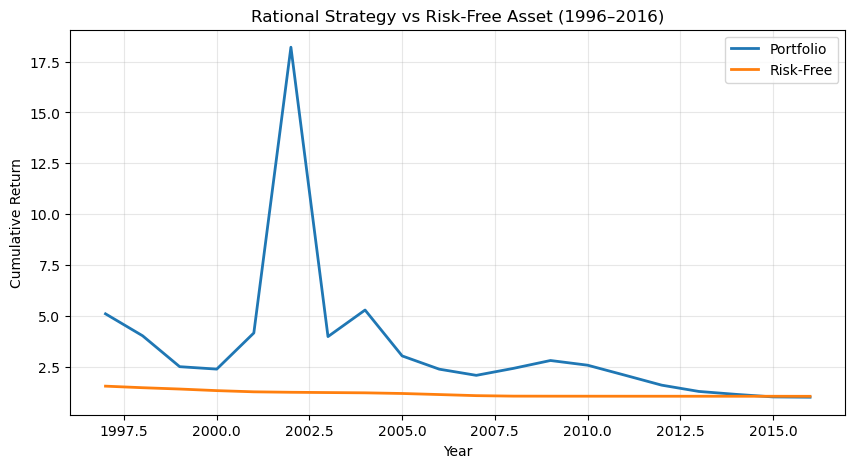

In [57]:
# plt.plot(graph.index, graph["portfolio_return"], label="Portfolio Return")
# plt.plot(graph.index, graph["risk_free_return"], label="Risk-Free Return")

plt.figure(figsize=(10,5))

plt.plot(graph.index, graph["portfolio_return"], linewidth=2)
plt.plot(graph.index, graph["risk_free_return"], linewidth=2)

plt.xlabel("Year")
plt.ylabel("Cumulative Return")
plt.title("Rational Strategy vs Risk-Free Asset (1996–2016)")
plt.legend(["Portfolio", "Risk-Free"])
plt.grid(alpha=0.3)

plt.savefig("Rational Strategy vs Risk-Free Asset (1996–2016)")
plt.show()

In [ ]:
final = "2016-09-23"
begin = "1996-02-28"

In [63]:
# get a list of all the companies in it the whole time
# can remove YRCW
# do average return 

a = df.columns

In [85]:
invest(['ADP'],"1996-02-28","2016-09-23",100, "equal",df)


(821.9308, 8.2193)

In [79]:
a

Index(['1436513D', 'AAPL', 'ABC', 'ABMD', 'ABT', 'ABX', 'ADBE', 'ADI', 'ADM',
       'ADP',
       ...
       'WY', 'X', 'XEL', 'XL', 'XLNX', 'XOM', 'XRAY', 'XRX', 'YRCW', 'ZION'],
      dtype='object', name='ticker', length=456)

In [89]:
get_data_until("2016-09-23").describe()

,minimum price,maximum price,mean price,start_price,end_price,% growth,mean_return / day,volatility / day,sharpe ratio,VaR
count,456.000000,456.000000,456.000000,456.000000,456.000000,456.000000,456.000000,456.000000,456.000000,456.000000
mean,5.595798,1138.446551,293.213362,169.687513,65.940432,1677.100150,0.000683,0.024633,0.028686,-0.034378
std,6.814588,22263.103504,5586.562255,3373.200034,64.554844,14516.538319,0.000252,0.007318,0.008590,0.009389
min,0.013000,12.876900,4.546784,0.016000,1.640000,-99.982857,-0.000140,0.011529,-0.002575,-0.065763
25%,2.348175,48.479725,18.369101,4.595625,30.545050,261.010040,0.000519,0.019153,0.022948,-0.040593
50%,4.423350,70.816050,25.726863,8.210900,49.656600,620.295133,0.000638,0.023419,0.028856,-0.032973
75%,7.803400,108.256175,36.504552,13.112300,78.926750,1128.105725,0.000792,0.029157,0.034409,-0.026915
max,124.138000,475500.047600,119325.824141,72042.189200,744.850000,309231.250000,0.002306,0.054991,0.058799,-0.017096
